### Setting

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import imageio
import numpy as np
import pandas as pd
from PIL import Image
from typing import Dict

from hex.model.tools import read_mode_config
from hex.model.framework.base_framework import baseframework

/mnt/dataset/vnwy44/miniconda3/envs/hex/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Visualization

In [2]:
df = pd.read_parquet("./dataset/episode_000533.parquet")
print(df['action'][80])
print(df['observation.state'][0])

[-5.22613347e-01  5.70082247e-01  2.00435836e-02  7.21680641e-01
 -2.88373321e-01  1.51654884e-01 -9.64624166e-01 -6.13634229e-01
 -6.13663137e-01 -2.93654613e-02  4.10595983e-01  4.40357000e-01
  2.88419485e-01  1.45172071e+00 -1.04813971e+00  7.85302198e-01
  2.45107006e-03  1.00000005e-03  1.00000005e-03  1.00000005e-03
  1.00000005e-03 -7.19730037e-01 -6.70798150e-01 -6.65704905e-04
 -1.00000005e-03 -1.00000005e-03 -1.00000005e-03 -1.00000005e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  6.51969135e-01]
[-0.32349169  0.57810688 -0.04785331  0.08442699 -0.47735804  0.24207845
 -1.28274596 -0.50623548 -0.55556661  0.00624023  0.42563784  0.40633723
  0.13646084  1.42668331 -0.98819822  0.76493323  0.03481857 -0.01836138
 -0.03294807 -0.04661843 -0.01889869 -0.70397192 -0.64518398 -0.01573868
  0.01512851  0.02032146  0.0130587   0.02670283 -0.50054318 -0.06777707
 -0.09292171  1.10641491 -0.56553942 -0.01179963 -0.50162995  0.0501816
  0.09383151  1.10863948 -0.56764162  0.02

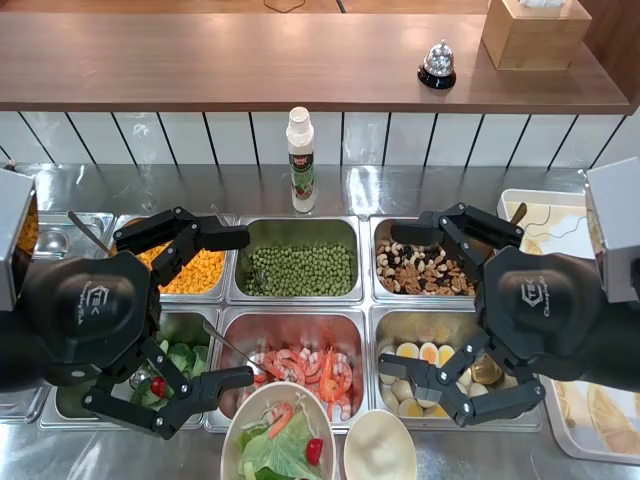

RGB
(480, 640, 3)
uint8


In [3]:
video_path = "./dataset/episode_000533.mp4"

reader = imageio.get_reader(video_path)
frame = reader.get_data(0)   # first frame
reader.close()

pil_img = Image.fromarray(frame)    # rgb
pil_img.show()
print(pil_img.mode)

arr = np.array(pil_img)
print(arr.shape)      # (H, W, 3)
print(arr.dtype)      # uint8

### Load and Evaluate Model

In [5]:
model_path = '../pretrained_models/EAI_real_world_2B/hex_ac100_300k_8gpu_state_query_history2/checkpoints/steps_300000_pytorch_model.pt'
infer_model = baseframework.from_pretrained(model_path)
infer_model = infer_model.to(torch.bfloat16)
infer_model = infer_model.to("cuda").eval()

instruction = ["Make a salad"]

05/17 [17:55:06] INFO     | >> [*] Loading from local checkpoint path                            ]8;id=674947;file:///mnt/dataset/vnwy44/code/HEX/hex/model/framework/share_tools.py\share_tools.py]8;;\:]8;id=977890;file:///mnt/dataset/vnwy44/code/HEX/hex/model/framework/share_tools.py#246\246]8;;\
                          `../pretrained_models/EAI_real_world_2B/hex_ac100_300k_8gpu_state_quer                   
                          y_history2/checkpoints/steps_300000_pytorch_model.pt`                                    

[EmbodimentRegistry] Saved registry to pretrained_models/hex/EAI_real_world_2B/hex_ac100_300k_8gpu_state_query_history2/embodiment_registry.json
Total number of DiT parameters:  122441736


In [6]:
class Normalizer:
    valid_modes = ["q99", "mean_std", "min_max", "binary"]

    def __init__(self, mode: str, statistics: dict):
        self.mode = mode
        self.statistics = statistics
        for key, value in self.statistics.items():
            self.statistics[key] = torch.tensor(value)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert isinstance(
            x, torch.Tensor
        ), f"Unexpected input type: {type(x)}. Expected type: {torch.Tensor}"

        # Normalize the tensor
        if self.mode == "q99":
            # Range of q99 is [-1, 1]
            q01 = self.statistics["q01"].to(x.dtype)
            q99 = self.statistics["q99"].to(x.dtype)

            # In the case of q01 == q99, the normalization will be undefined
            # So we set the normalized values to the original values
            mask = q01 != q99
            normalized = torch.zeros_like(x)

            # Normalize the values where q01 != q99
            # Formula: 2 * (x - q01) / (q99 - q01) - 1
            normalized[..., mask] = (x[..., mask] - q01[..., mask]) / (
                q99[..., mask] - q01[..., mask]
            )
            normalized[..., mask] = 2 * normalized[..., mask] - 1

            # Set the normalized values to the original values where q01 == q99
            normalized[..., ~mask] = x[..., ~mask].to(x.dtype)

            # Clip the normalized values to be between -1 and 1
            normalized = torch.clamp(normalized, -1, 1)

        elif self.mode == "mean_std":
            # Range of mean_std is not fixed, but can be positive or negative
            mean = self.statistics["mean"].to(x.dtype)
            std = self.statistics["std"].to(x.dtype)

            # In the case of std == 0, the normalization will be undefined
            # So we set the normalized values to the original values
            mask = std != 0
            normalized = torch.zeros_like(x)

            # Normalize the values where std != 0
            # Formula: (x - mean) / std
            normalized[..., mask] = (x[..., mask] - mean[..., mask]) / std[..., mask]

            # Set the normalized values to the original values where std == 0
            normalized[..., ~mask] = x[..., ~mask].to(x.dtype)

        elif self.mode == "min_max":
            # Range of min_max is [-1, 1]
            min = self.statistics["min"].to(x.dtype)
            max = self.statistics["max"].to(x.dtype)

            # In the case of min == max, the normalization will be undefined
            # So we set the normalized values to the original values
            mask = min != max
            normalized = torch.zeros_like(x)

            # Normalize the values where min != max
            # Formula: 2 * (x - min) / (max - min) - 1
            normalized[..., mask] = (x[..., mask] - min[..., mask]) / (
                max[..., mask] - min[..., mask]
            )
            normalized[..., mask] = 2 * normalized[..., mask] - 1

            # Set the normalized values to the original values where min == max
            # normalized[..., ~mask] = x[..., ~mask].to(x.dtype)
            # Set the normalized values to 0 where min == max
            normalized[..., ~mask] = 0

        elif self.mode == "scale":
            # Range of scale is [0, 1]
            min = self.statistics["min"].to(x.dtype)
            max = self.statistics["max"].to(x.dtype)
            abs_max = torch.max(torch.abs(min), torch.abs(max))
            mask = abs_max != 0
            normalized = torch.zeros_like(x)
            normalized[..., mask] = x[..., mask] / abs_max[..., mask]
            normalized[..., ~mask] = 0

        elif self.mode == "binary":
            # Range of binary is [0, 1]
            normalized = (x > 0.5).to(x.dtype)
        else:
            raise ValueError(f"Invalid normalization mode: {self.mode}")

        return normalized

    def inverse(self, x: torch.Tensor) -> torch.Tensor:
        assert isinstance(
            x, torch.Tensor
        ), f"Unexpected input type: {type(x)}. Expected type: {torch.Tensor}"
        if self.mode == "q99":
            q01 = self.statistics["q01"].to(x.dtype)
            q99 = self.statistics["q99"].to(x.dtype)
            return (x + 1) / 2 * (q99 - q01) + q01
        elif self.mode == "mean_std":
            mean = self.statistics["mean"].to(x.dtype)
            std = self.statistics["std"].to(x.dtype)
            return x * std + mean
        elif self.mode == "min_max":
            min = self.statistics["min"].to(x.dtype)
            max = self.statistics["max"].to(x.dtype)
            return (x + 1) / 2 * (max - min) + min
        elif self.mode == "binary":
            return (x > 0.5).to(x.dtype)
        else:
            raise ValueError(f"Invalid normalization mode: {self.mode}")

In [7]:
infer_model.norm_stats

{'tienkung2_v1': {'action': {'mean': [-0.0003965191141126146,
    0.0013129088929486243,
    0.0014843982989097028,
    -0.00022670627107733912,
    -0.0005513659235524712,
    -0.0024663440256824753,
    0.0005381562404680431,
    0.0,
    -0.004324341059628514,
    -0.001852741766454584,
    -0.0011478450097882162,
    -0.005931225893937209,
    0.00032187702889125347,
    -0.004200430855697191,
    0.0016724831860517168,
    1.1929770676860843e-05,
    0.0002980433694242384,
    0.006016429275311669,
    0.0006562193184904053,
    0.0,
    0.0,
    -0.0006659932275638077,
    0.01340800635937316],
   'std': [0.004492808686630086,
    0.01061888523299691,
    0.013028865083789625,
    0.004007827701803608,
    0.006481535165595784,
    0.020743786859589445,
    0.005394736114768051,
    0.0,
    0.04256683841874276,
    0.0193757116648689,
    0.04502628250741447,
    0.07008695478147597,
    0.016653609643585685,
    0.03829353070716905,
    0.020692347047117986,
    0.0001318023746

In [8]:
norm_stats = infer_model.norm_stats['unitree_g1_v2']
action_norm_stats = norm_stats["action"]
print('action: ', action_norm_stats)
state_norm_stats = norm_stats["state"]
print('state: ', state_norm_stats)

action:  {'mean': [-0.24589035023944655, 0.19997476816449808, -0.007247966394608971, 0.15379699174729403, -0.13310314643955146, 0.13983810830168644, -0.3945512672741687, -0.28151174471527446, -0.22859902819076036, -0.012495177326035155, 0.24124574803348775, 0.11719636992803618, 0.11354351181915516, 0.42991143371986645, -0.29559734262516674, 0.24888415643659884, 0.2405381123747508, -0.1975832943967323, -0.2004643992305023, -0.19002478615596005, -0.178042651894418, -0.14000992384886285, -0.3138013125213803, -0.0037522066443731895, 0.15591115980349157, 0.31122655449131276, 0.11851715221351711, 0.3112079043170865, 0.0, 0.0, 0.0, 0.25044603319466363], 'std': [0.35159690952426426, 0.2816907233578582, 0.13550237634919327, 0.3073008334336926, 0.25994441047230543, 0.3057797223148312, 0.52407841520995, 0.38404639437499316, 0.303824834147167, 0.1538239908426567, 0.369520292688084, 0.2443855950102046, 0.2984330170024465, 0.5651562428480055, 0.4452596877962797, 0.3333452074269018, 0.571458159576590

In [9]:
video_path = "./dataset/episode_000533.mp4"

step = 0
reader = imageio.get_reader(video_path)
frame = reader.get_data(step) 
reader.close()

pil_img = Image.fromarray(frame).resize((224, 224), Image.Resampling.LANCZOS)    # rgb
batch_images = [[pil_img]]

normalizer_state = Normalizer('q99', state_norm_stats)
normalizer_action = Normalizer('q99', action_norm_stats)

# state = None
state = np.stack([df['observation.state'][step]])
state = torch.from_numpy(np.array(state))
state = normalizer_state.forward(state).unsqueeze(0)

tags = ['unitree_g1_v2']

infer_model.reset()
action_pred: np.ndarray = infer_model.predict_action(batch_images, instruction, state, tags)['normalized_actions'][0][:, :32]

In [10]:
unnorm_action_pred = normalizer_action.inverse(torch.tensor(action_pred))
unnorm_action_pred = unnorm_action_pred.numpy()
print('predict action:', unnorm_action_pred[0])

actual_actions = np.stack(df['action'][step]) 
print('ground-truth action:', df['action'][step])

predict action: [-3.9268422e-01  5.7117486e-01 -2.5644422e-02  1.2033230e-01
 -4.7851872e-01  3.0811644e-01 -1.2528393e+00 -5.2095449e-01
 -6.2739074e-01 -6.1850071e-02  3.8879174e-01  4.9499619e-01
  1.8790448e-01  1.4798112e+00 -1.0502946e+00  7.8362465e-01
 -3.0741808e-03  4.1598082e-03  5.2642822e-03  3.9616823e-03
  1.1630893e-02 -7.1325624e-01 -6.7093086e-01 -6.8307109e-04
 -7.9717836e-05 -3.1641074e-03 -6.0273334e-04 -2.3476756e-03
  0.0000000e+00  0.0000000e+00  0.0000000e+00  6.8466073e-01]
ground-truth action: [-3.38302374e-01  5.85061371e-01 -4.72131334e-02  9.09681171e-02
 -4.80936021e-01  2.38196567e-01 -1.30128038e+00 -5.26758254e-01
 -5.61134756e-01  5.25003998e-03  4.42387849e-01  4.06350106e-01
  1.28401294e-01  1.44867134e+00 -1.04813971e+00  7.85302198e-01
  2.45107006e-03  1.00000005e-03  1.00000005e-03  1.00000005e-03
  1.00000005e-03 -7.19730037e-01 -6.70798150e-01 -6.65704905e-04
 -1.00000005e-03 -1.00000005e-03 -1.00000005e-03 -1.00000005e-03
 -0.00000000e+00 -0

In [11]:
action_chunk = 20
if step + action_chunk > len(df['action']):
    action_chunk = len(df['action']) - step
actual_actions = np.stack(df['action'][step: step+action_chunk]) 
mse = np.mean((action_pred[0:action_chunk] - actual_actions) ** 2)
print('mse score: ', mse)

mse:  0.49832319729024277
